In [1]:
import pandas as pd

# 读取上传的新闻情绪数据
file_path = "/content/daily_sentiment_weighted_monthly_vader.csv"
df = pd.read_csv(file_path)

# 查看前几行数据
print(df.head())

  created_time  weighted_sentiment  sentiment_score      score  comment_count
0   2024-05-01            0.078145         0.057724  71.365517            145
1   2024-05-02           -0.167322        -0.139720  52.076923            143
2   2024-05-03           -0.087577        -0.095586  65.918919            111
3   2024-05-04            0.457298         0.422143  48.619048             84
4   2024-05-05            0.190895         0.114737  40.263158             38


In [10]:
import pandas as pd

# 读取数据
file_path = "/content/daily_sentiment_weighted_monthly_vader.csv"
df = pd.read_csv(file_path)

# 转换日期格式（保留日期部分）
df['created_time'] = pd.to_datetime(df['created_time']).dt.date

# 统计每个日期的新闻数量
#news_count_per_day = df.groupby('publishedAt').size()
print(df.head())

  created_time  weighted_sentiment  sentiment_score      score  comment_count
0   2024-05-01            0.078145         0.057724  71.365517            145
1   2024-05-02           -0.167322        -0.139720  52.076923            143
2   2024-05-03           -0.087577        -0.095586  65.918919            111
3   2024-05-04            0.457298         0.422143  48.619048             84
4   2024-05-05            0.190895         0.114737  40.263158             38


In [3]:
import yfinance as yf

# 下载 Tesla 股票数据
tsla = yf.download('TSLA', start='2024-05-01', end='2025-04-12')

# 打印前几行数据，检查列名
print(tsla.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2024-05-01  179.990005  185.860001  179.009995  182.000000  92829700
2024-05-02  180.009995  184.600006  176.020004  182.860001  89148000
2024-05-03  181.190002  184.779999  178.419998  182.100006  75491500
2024-05-06  184.759995  187.559998  182.199997  183.800003  84390300
2024-05-07  177.809998  183.259995  177.399994  182.399994  75045900


In [8]:
import yfinance as yf
import pandas as pd

# Download Tesla stock data
tsla = yf.download('TSLA', start='2024-05-01', end='2025-04-12')

# Fix MultiIndex issue and rename columns
tsla.columns = tsla.columns.get_level_values(0)

# Keep only the closing price
tsla = tsla[['Close']]

# Reset index and rename columns
tsla.reset_index(inplace=True)
tsla.rename(columns={'Date': 'created_time', 'Close': 'TSLA_Close'}, inplace=True)

# Ensure 'publishedAt' in tsla is datetime
tsla['created_time'] = pd.to_datetime(tsla['created_time'])

# Ensure 'publishedAt' in daily_sentiment is datetime
df['created_time'] = pd.to_datetime(df['created_time'])

# Merge sentiment data with stock price data
df_merged = pd.merge(tsla, df, on='created_time', how='inner')

# Check the merged data
print(df_merged.head())
print(df_merged.isnull().sum())

[*********************100%***********************]  1 of 1 completed

  created_time  TSLA_Close  weighted_sentiment  sentiment_score      score  \
0   2024-05-01  179.990005            0.078145         0.057724  71.365517   
1   2024-05-02  180.009995           -0.167322        -0.139720  52.076923   
2   2024-05-03  181.190002           -0.087577        -0.095586  65.918919   
3   2024-05-06  184.759995            0.092019         0.134630  22.111111   
4   2024-05-07  177.809998            0.160931         0.133465  21.198020   

   comment_count  
0            145  
1            143  
2            111  
3             54  
4            101  
created_time          0
TSLA_Close            0
weighted_sentiment    0
sentiment_score       0
score                 0
comment_count         0
dtype: int64


In [5]:
%matplotlib inline

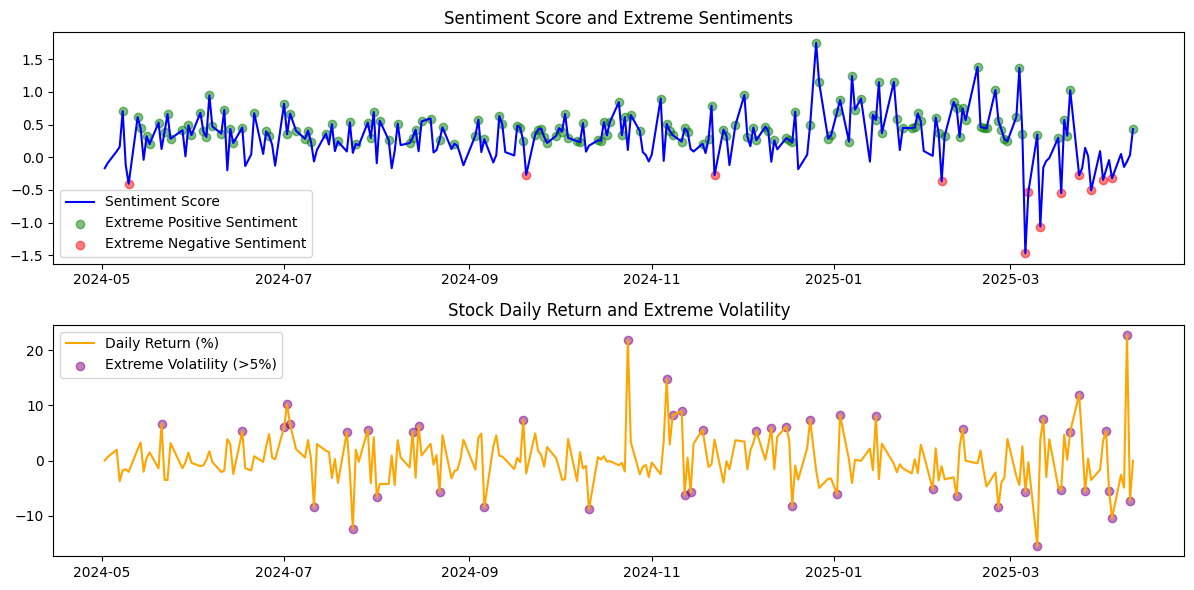

极端正面情绪日期: ['2024-05-08', '2024-05-13', '2024-05-14', '2024-05-16', '2024-05-17', '2024-05-20', '2024-05-22', '2024-05-23', '2024-05-24', '2024-05-28', '2024-05-30', '2024-05-31', '2024-06-03', '2024-06-04', '2024-06-05', '2024-06-06', '2024-06-07', '2024-06-10', '2024-06-11', '2024-06-13', '2024-06-14', '2024-06-17', '2024-06-21', '2024-06-25', '2024-06-26', '2024-07-01', '2024-07-02', '2024-07-03', '2024-07-05', '2024-07-08', '2024-07-09', '2024-07-10', '2024-07-15', '2024-07-17', '2024-07-19', '2024-07-23', '2024-07-25', '2024-07-29', '2024-07-30', '2024-07-31', '2024-08-02', '2024-08-05', '2024-08-08', '2024-08-12', '2024-08-13', '2024-08-14', '2024-08-16', '2024-08-19', '2024-08-22', '2024-08-23', '2024-08-27', '2024-09-03', '2024-09-04', '2024-09-06', '2024-09-11', '2024-09-12', '2024-09-17', '2024-09-18', '2024-09-19', '2024-09-23', '2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27', '2024-09-30', '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04', '2024-10-07', '2024-10-

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设 df_merged 是你已经处理好的数据
# 确保将 publishedAt 设置为索引，并将其转换为日期格式
df_merged['created_time'] = pd.to_datetime(df_merged['created_time'])
df_merged.set_index('created_time', inplace=True)

# 提取情绪的极端值
extreme_positive = df_merged[df_merged['weighted_sentiment'] > 0.2]  # 情绪分数 > 0.1 的极端正面情绪
extreme_negative = df_merged[df_merged['weighted_sentiment'] < -0.2]  # 情绪分数 < -0.1 的极端负面情绪

# 计算股票的日涨跌幅
df_merged['daily_return'] = df_merged['TSLA_Close'].pct_change() * 100  # 收盘价的涨跌幅

# 标记大波动的日期，定义波动幅度大于5%为大波动
extreme_volatility = df_merged[abs(df_merged['daily_return']) > 5]
df_merged.dropna(subset=['weighted_sentiment', 'TSLA_Close','daily_return'], inplace=True)

# 可视化情绪极端值与股价大波动的关系
plt.figure(figsize=(12, 6))

# 绘制情绪分数的时间序列
plt.subplot(2, 1, 1)
plt.plot(df_merged.index, df_merged['weighted_sentiment'], label='Sentiment Score', color='blue')
plt.scatter(extreme_positive.index, extreme_positive['weighted_sentiment'], color='green', label='Extreme Positive Sentiment', alpha=0.5)
plt.scatter(extreme_negative.index, extreme_negative['weighted_sentiment'], color='red', label='Extreme Negative Sentiment', alpha=0.5)
plt.title('Sentiment Score and Extreme Sentiments')
plt.legend()

# 绘制股票日涨跌幅的时间序列
plt.subplot(2, 1, 2)
plt.plot(df_merged.index, df_merged['daily_return'], label='Daily Return (%)', color='orange')
plt.scatter(extreme_volatility.index, extreme_volatility['daily_return'], color='purple', label='Extreme Volatility (>5%)', alpha=0.5)
plt.title('Stock Daily Return and Extreme Volatility')
plt.legend()

plt.tight_layout()
plt.savefig('sentiment_and_volatility.png', dpi=300)  # 保存为PNG格式，300dpi高清
plt.show()

# 打印极端情绪和大波动的相关性
print(f"极端正面情绪日期: {extreme_positive.index.strftime('%Y-%m-%d').tolist()}")
print(f"极端负面情绪日期: {extreme_negative.index.strftime('%Y-%m-%d').tolist()}")
print(f"大波动日期: {extreme_volatility.index.strftime('%Y-%m-%d').tolist()}")
# 提取日期列表并转换为 set
pos_dates = set(extreme_positive.index.strftime('%Y-%m-%d').tolist())
neg_dates = set(extreme_negative.index.strftime('%Y-%m-%d').tolist())
vol_dates = set(extreme_volatility.index.strftime('%Y-%m-%d').tolist())

# 求交集
pos_and_vol = pos_dates & vol_dates
neg_and_vol = neg_dates & vol_dates
pos_and_neg = pos_dates & neg_dates
all_three = pos_dates & neg_dates & vol_dates

# 打印交集结果
print("\n=== 日期交集分析 ===")
print(f"极端正面情绪 ∩ 大波动 日期数量: {len(pos_and_vol)}")
print(sorted(pos_and_vol))

print(f"极端负面情绪 ∩ 大波动 日期数量: {len(neg_and_vol)}")
print(sorted(neg_and_vol))

print(f"极端正面情绪 ∩ 极端负面情绪 日期数量: {len(pos_and_neg)}")
print(sorted(pos_and_neg))

print(f"三者交集 日期数量: {len(all_three)}")
print(sorted(all_three))

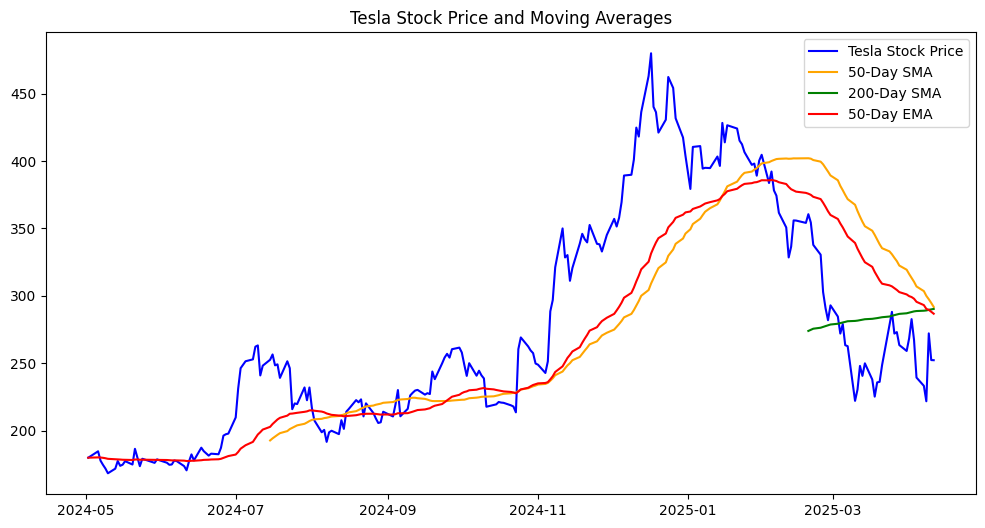

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 计算简单移动平均 (SMA) 和指数加权移动平均 (EMA)
df_merged['SMA_50'] = df_merged['TSLA_Close'].rolling(window=50).mean()  # 50天简单移动平均
df_merged['SMA_200'] = df_merged['TSLA_Close'].rolling(window=200).mean()  # 200天简单移动平均
df_merged['EMA_50'] = df_merged['TSLA_Close'].ewm(span=50, adjust=False).mean()  # 50天指数加权移动平均



# 可视化移动平均和股票价格
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['TSLA_Close'], label='Tesla Stock Price', color='blue')
plt.plot(df_merged.index, df_merged['SMA_50'], label='50-Day SMA', color='orange')
plt.plot(df_merged.index, df_merged['SMA_200'], label='200-Day SMA', color='green')
plt.plot(df_merged.index, df_merged['EMA_50'], label='50-Day EMA', color='red')
plt.title('Tesla Stock Price and Moving Averages')
plt.legend()
plt.savefig('Tesla Stock Price and Moving Averages.png', dpi=300)  # 保存为PNG格式，300dpi高清
plt.show()



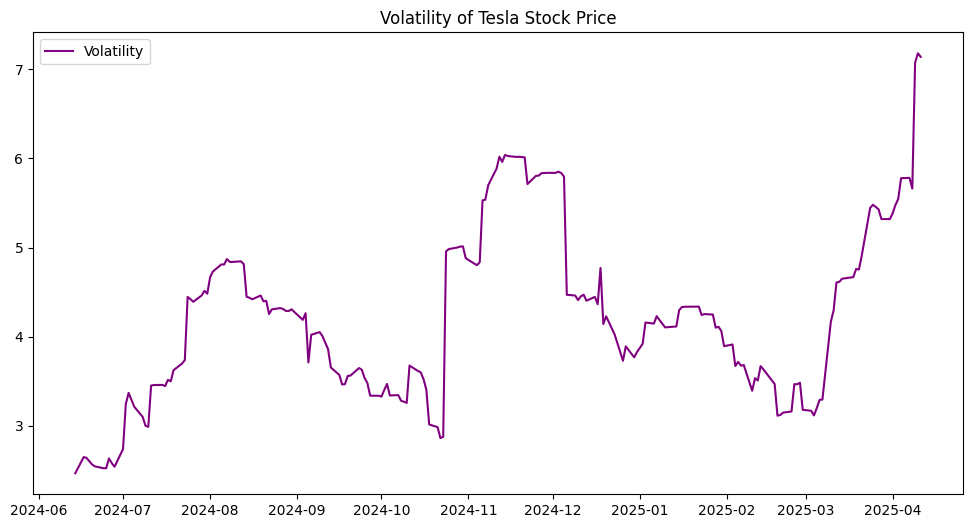

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_merged['daily_return'] = df_merged['TSLA_Close'].pct_change() * 100  # 收盘价的涨跌幅
df_merged['volatility'] = df_merged['daily_return'].rolling(window=30).std()  # 30日滚动标准差作为波动率

# 可视化波动率
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index, df_merged['volatility'], label='Volatility', color='purple')
plt.title('Volatility of Tesla Stock Price')
plt.legend()
plt.savefig('Volatility of Tesla Stock Price.png', dpi=300)  # 保存为PNG格式，300dpi高清
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.2178
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0453
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0461
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0290
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0242
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0220
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0162
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0123
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0137
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0139
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


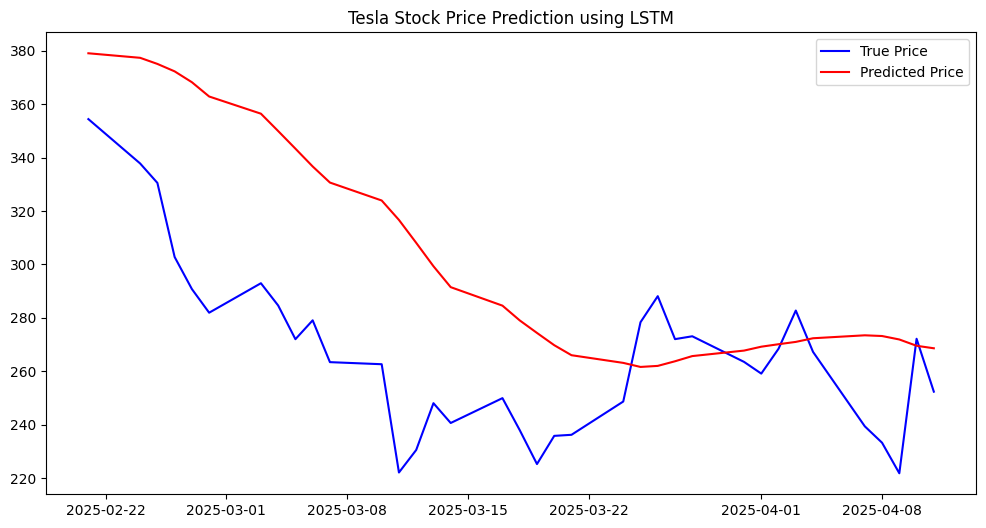

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 特征选择
features = ['TSLA_Close', 'weighted_sentiment']  # 可以加入更多特征

# 归一化数据
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_merged[features].values)

# 准备数据，生成时间步长
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step, 0])  # 预测 TSLA_Close
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, time_step=60)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 构建 LSTM 模型
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# 编译模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 训练模型
model.fit(X_train, y_train, epochs=10, batch_size=32)

# 预测
predictions = model.predict(X_test)

# 反归一化
predictions = scaler.inverse_transform(np.column_stack((predictions, np.zeros(len(predictions)))))[:, 0]
y_test = scaler.inverse_transform(np.column_stack((y_test, np.zeros(len(y_test)))))[:, 0]

# 可视化预测结果
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index[-len(y_test):], y_test, label='True Price', color='blue')
plt.plot(df_merged.index[-len(y_test):], predictions, label='Predicted Price', color='red')
plt.title('Tesla Stock Price Prediction using LSTM')
plt.legend()
plt.savefig('Tesla Stock Price Prediction using LSTM', dpi=300)  # 保存为PNG格式，300dpi高清
plt.show()

In [ ]:
pip install --upgrade matplotlib

In [ ]:
pip install pandas_ta


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=91897a0a926d3a450ae7ac2d942ba16c78ea3edb53a1fe94cf7ebc78665a5854
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [ ]:
%matplotlib inline

         Date            Action       Price  Shares           Cash  Position
0  2024-07-15               BUY  252.006076      19   95207.096446        19
1  2024-07-17               BUY  250.740050      19   90438.271433        38
2  2024-07-19  SELL (Stop Loss)  240.309856      38   99560.914185         0
3  2024-09-23               BUY  250.493292      19   94796.782256        19
4  2024-09-24               BUY  252.520721      18   90246.863898        37
5  2024-09-25               BUY  255.251663      17   85903.246343        54
6  2024-09-30               BUY  259.317633      16   81750.015130        70
7  2024-10-01               BUY  259.909604      15   77847.472421        85
8  2024-10-02  SELL (Stop Loss)  249.523597      85   99035.768702         0
9  2024-10-25               BUY  270.310224      18   94165.319093        18
10 2024-10-28  SELL (Stop Loss)  259.992982      18   98840.512902         0
11 2024-11-01               BUY  251.319959      19   94060.658606        19

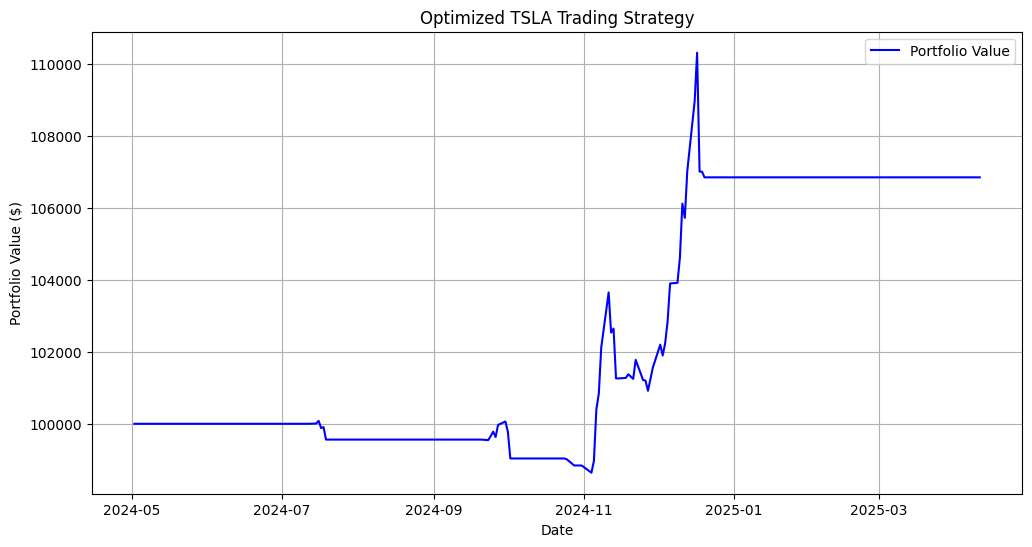

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设 df_merged 是你已经处理好的数据
initial_cash = 100000
cash = initial_cash
position = 0
position_entry_price = 0
max_profit = 0
trade_log = []
portfolio_values = [initial_cash]

# 策略参数
buy_threshold = 0.03
sell_threshold = -0.03
transaction_fee = 0.001
slippage = 0.01  # 更贴近现实
kelly_fraction = 0.05

take_profit_trailing_ratio = 0.7  # 浮动止盈
stop_loss_ratio = 0.02

np.random.seed(42)

# 技术指标
df_merged['20_day_MA'] = df_merged['TSLA_Close'].rolling(window=20).mean()
df_merged['50_day_MA'] = df_merged['TSLA_Close'].rolling(window=50).mean()
df_merged['12_EMA'] = df_merged['TSLA_Close'].ewm(span=12, adjust=False).mean()
df_merged['26_EMA'] = df_merged['TSLA_Close'].ewm(span=26, adjust=False).mean()
df_merged['MACD'] = df_merged['12_EMA'] - df_merged['26_EMA']
df_merged['MACD_signal'] = df_merged['MACD'].ewm(span=9, adjust=False).mean()

for i in range(1, len(df_merged)):
    date = df_merged.index[i]
    sentiment = df_merged['weighted_sentiment'].iloc[i]
    prev_sentiment = df_merged['weighted_sentiment'].iloc[i - 1]
    sentiment_diff = sentiment - prev_sentiment

    close_price = df_merged['TSLA_Close'].iloc[i]
    ma_20 = df_merged['20_day_MA'].iloc[i]
    ma_50 = df_merged['50_day_MA'].iloc[i]
    macd = df_merged['MACD'].iloc[i]
    macd_signal = df_merged['MACD_signal'].iloc[i]

    def apply_slippage(price):
        return price * (1 + np.random.uniform(-slippage, slippage))

    # 动态仓位
    position_size = cash * kelly_fraction / close_price
    shares_to_trade = int(position_size)

    # 买入
    if (sentiment > buy_threshold and sentiment_diff > 0 and
        close_price > ma_20 and ma_20 > ma_50 and
        macd > macd_signal and cash >= close_price * shares_to_trade):

        adjusted_price = apply_slippage(close_price)
        cost = shares_to_trade * adjusted_price * (1 + transaction_fee)
        cash -= cost
        position += shares_to_trade
        position_entry_price = adjusted_price
        max_profit = 0  # 初始化浮盈追踪
        trade_log.append((date, 'BUY', adjusted_price, shares_to_trade, cash, position))

    # 卖出
    elif (sentiment < sell_threshold and sentiment_diff < 0 and
          close_price < ma_20 and ma_20 < ma_50 and
          macd < macd_signal and position > 0):

        adjusted_price = apply_slippage(close_price)
        cash += position * adjusted_price * (1 - transaction_fee)
        trade_log.append((date, 'SELL', adjusted_price, position, cash, 0))
        position = 0
        max_profit = 0

    # 止盈/止损
    if position > 0:
        current_profit = (close_price - position_entry_price) / position_entry_price
        max_profit = max(max_profit, current_profit)

        if current_profit <= max_profit * take_profit_trailing_ratio and current_profit > 0:
            adjusted_price = apply_slippage(close_price)
            cash += position * adjusted_price * (1 - transaction_fee)
            trade_log.append((date, 'SELL (Take Profit)', adjusted_price, position, cash, 0))
            position = 0
            max_profit = 0

        elif current_profit <= -stop_loss_ratio:
            adjusted_price = apply_slippage(close_price)
            cash += position * adjusted_price * (1 - transaction_fee)
            trade_log.append((date, 'SELL (Stop Loss)', adjusted_price, position, cash, 0))
            position = 0
            max_profit = 0

    portfolio_value = cash + position * close_price
    portfolio_values.append(portfolio_value)

# 输出结果
final_value = cash + (position * df_merged['TSLA_Close'].iloc[-1])
years = (df_merged.index[-1] - df_merged.index[0]).days / 365.25
annualized_return = (final_value / initial_cash) ** (1 / years) - 1

df_log = pd.DataFrame(trade_log, columns=["Date", "Action", "Price", "Shares", "Cash", "Position"])
print(df_log)
print(f"\n初始资金: ${initial_cash:.2f}")
print(f"最终资金: ${final_value:.2f}")
print(f"策略总收益: {(final_value - initial_cash) / initial_cash * 100:.2f}%")
print(f"年化收益率: {annualized_return * 100:.2f}%")

# 资金曲线图
plt.figure(figsize=(12, 6))
plt.plot(df_merged.index[:len(portfolio_values)], portfolio_values, label="Portfolio Value", color="blue")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Optimized TSLA Trading Strategy")
plt.legend()
plt.grid(True)
plt.savefig('Optimized TSLA Trading Strategy', dpi=300)  # 保存为PNG格式，300dpi高清
plt.show()
